# XTX experiment
## generate random N, d and nu/d
## define a corresponding N * d X
## calculate XTX = X.T @ X
## calculate PP(XTX)
## this should be nu(lambda^2), if PP(X) = nu(lambda)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [3]:
#N = 500
#d = 200

num_iterations = 100
scale_factor = 200

#nu_over_d = 0.5
uniform_draws = True
verbose = False
force_cpu = False

nu_over_d_X_vals = np.zeros(num_iterations)
nu_over_d_XTX_vals = np.zeros(num_iterations)
estimate_nu_over_d_XTX_vals = np.zeros(num_iterations)
nu_over_d_XT_times_nu_over_d_X_vals = np.zeros(num_iterations)
nu_Sigma_over_d_vals = np.zeros(num_iterations)
nu_Sigma_squared_over_d_vals = np.zeros(num_iterations)
nu_S_over_d_vals = np.zeros(num_iterations)
nu_S_squared_over_d_vals = np.zeros(num_iterations)
new_estimate_nu_over_d_XTX_vals = np.zeros(num_iterations)

for i in range(num_iterations):
    N = int(scale_factor * (3.0 + 2.0 * np.random.uniform(0,1)))
    d = N - int(scale_factor * (1.0 + np.random.uniform(0,1)))
    nu_over_d = math.sqrt(np.random.uniform(0,1))
    print(i, N, d, nu_over_d)
    xx = pp.calculate_pp_dim_X_pp_dim_XTX(N, d, nu_over_d, uniform_draws, verbose, force_cpu)

    nu_over_d_X = xx["nu_over_d_X"]
    nu_over_d_XTX = xx["nu_over_d_XTX"]
    estimate_nu_over_d_XTX = xx["estimate_nu_over_d_XTX"]
    nu_over_d_XT_times_nu_over_d_X = xx["nu_over_d_XT_times_nu_over_d_X"]
    nu_Sigma_over_d = xx["nu_Sigma_over_d"]
    nu_Sigma_squared_over_d = xx["nu_Sigma_squared_over_d"]
    nu_S_over_d = xx["nu_S_over_d"]
    nu_S_squared_over_d = xx["nu_S_squared_over_d"]
    new_estimate_nu_over_d_XTX = xx["new_estimate_nu_over_d_XTX"]

    #print(i, nu_over_d_X, nu_over_d_XTX, estimate_nu_over_d_XTX, nu_over_d_XT_times_nu_over_d_X, nu_Sigma_over_d, nu_Sigma_squared_over_d)
    print(i, "nu_over_d_X = ", nu_over_d_X) 
    print(i, "nu_over_d_XTX = ", nu_over_d_XTX) 
    print(i, "estimate_nu_over_d_XTX = ", estimate_nu_over_d_XTX) 
    print(i, "nu_over_d_XT_times_nu_over_d_X = ", nu_over_d_XT_times_nu_over_d_X) 
    print(i, "nu_Sigma_over_d = ", nu_Sigma_over_d) 
    print(i, "nu_Sigma_squared_over_d = ", nu_Sigma_squared_over_d)
    print(i, "nu_S_over_d = ", nu_S_over_d)
    print(i, "nu_S_squared_over_d = ", nu_S_squared_over_d)
    print(i, "new_estimate_nu_over_d_XTX = ", new_estimate_nu_over_d_XTX)

    nu_over_d_X_vals[i] = nu_over_d_X
    nu_over_d_XTX_vals[i] = nu_over_d_XTX
    estimate_nu_over_d_XTX_vals[i] = estimate_nu_over_d_XTX
    nu_over_d_XT_times_nu_over_d_X_vals[i] = nu_over_d_XT_times_nu_over_d_X
    nu_Sigma_over_d_vals[i] = nu_Sigma_over_d
    nu_Sigma_squared_over_d_vals[i] = nu_Sigma_squared_over_d
    nu_S_over_d_vals[i] = nu_S_over_d
    nu_S_squared_over_d_vals[i] = nu_S_squared_over_d
    new_estimate_nu_over_d_XTX_vals[i] = new_estimate_nu_over_d_XTX

    i+=1

                           


0 749 359 0.8555664450008573
 ** calculate_pp_dim_X_pp_dim_XTX : using GPU **
0 nu_over_d_X =  0.7460206475400062
0 nu_over_d_XTX =  0.2970907294009314
0 estimate_nu_over_d_XTX =  0.20319039292393587
0 nu_over_d_XT_times_nu_over_d_X =  0.26620879162013944
0 nu_Sigma_over_d =  0.8456177945027639
0 nu_Sigma_squared_over_d =  0.3561921337949022
0 nu_S_over_d =  0.7460206475400062
0 nu_S_squared_over_d =  0.29734393759965655
0 new_estimate_nu_over_d_XTX =  0.3679632802239631
1 938 593 0.5486175672508646
 ** calculate_pp_dim_X_pp_dim_XTX : using GPU **
1 nu_over_d_X =  0.43365646732320395
1 nu_over_d_XTX =  0.039395758115422744
1 estimate_nu_over_d_XTX =  0.034121685399206944
1 nu_over_d_XT_times_nu_over_d_X =  0.11877688288659716
1 nu_Sigma_over_d =  0.5114210984135815
1 nu_Sigma_squared_over_d =  0.04280920436095063
1 nu_S_over_d =  0.43365646732320395
1 nu_S_squared_over_d =  0.03939613758505217
1 new_estimate_nu_over_d_XTX =  0.039556665975585686
2 802 467 0.6471038684233967
 ** calcula

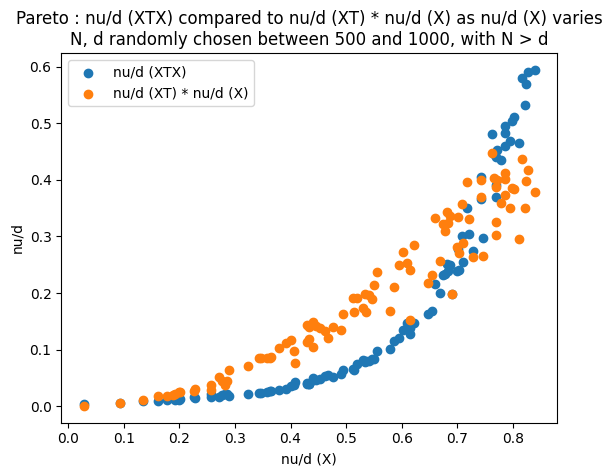

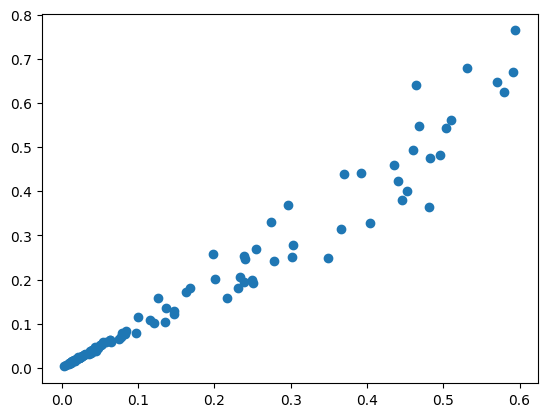

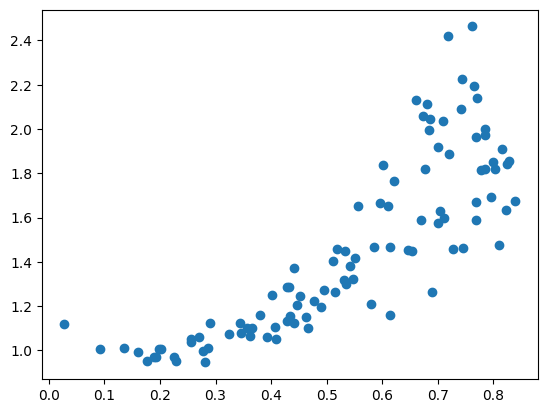

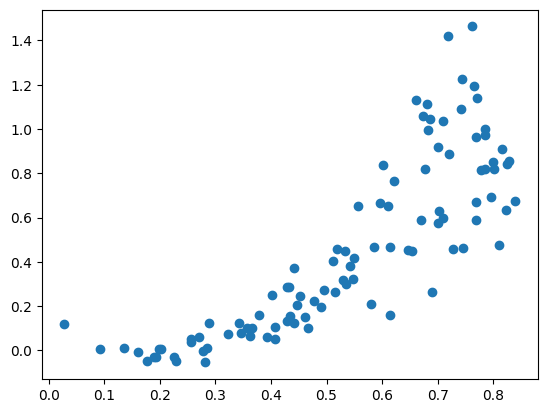

NameError: name 'this_vec_log' is not defined

In [5]:
this_title = "Pareto : nu/d (XTX) compared to nu/d (XT) * nu/d (X) as nu/d (X) varies\n"
this_title += "N, d randomly chosen between 500 and 1000, with N > d"
plt.scatter(nu_over_d_X_vals, nu_over_d_XTX_vals, label = "nu/d (XTX)")
#plt.scatter(nu_over_d_X_vals, estimate_nu_over_d_XTX_vals)
plt.scatter(nu_over_d_X_vals, nu_over_d_XT_times_nu_over_d_X_vals, label = "nu/d (XT) * nu/d (X)")
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
#plt.savefig('nu_over_d_X_nu_over_d_XTX_nu_over_d_XT_times_nu_over_d_X_pareto.pdf', dpi=300, bbox_inches='tight')
plt.show()

plt.scatter(nu_over_d_XTX_vals, new_estimate_nu_over_d_XTX_vals)
plt.show()

ratio_vals = nu_over_d_XTX_vals / estimate_nu_over_d_XTX_vals
plt.scatter(nu_over_d_X_vals, ratio_vals)
plt.show()

excess_ratio_vals = ratio_vals - 1.0
plt.scatter(nu_over_d_X_vals, excess_ratio_vals)
plt.show()

log_excess_ratio_vals = this_vec_log(ratio_vals - 1.0)
plt.scatter(nu_over_d_X_vals, log_excess_ratio_vals)
plt.show()

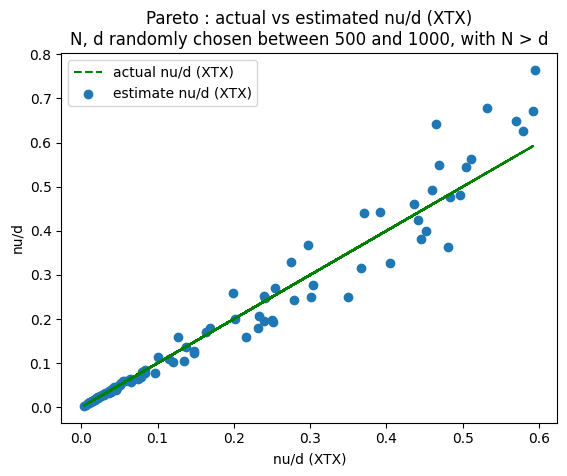

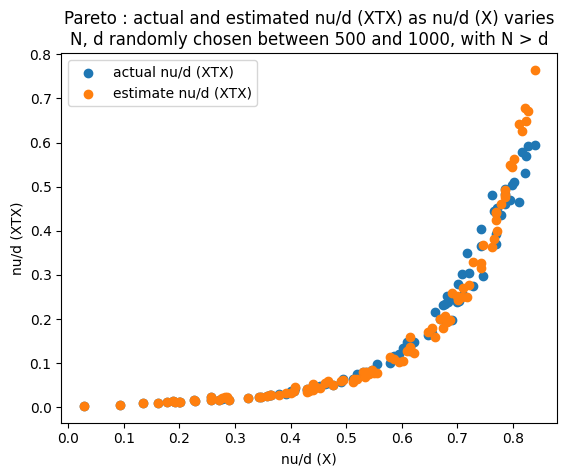

In [12]:
this_title = "Pareto : actual vs estimated nu/d (XTX)\n"
this_title += "N, d randomly chosen between 500 and 1000, with N > d"

plt.plot(nu_over_d_XTX_vals, nu_over_d_XTX_vals, linestyle = "--", color = "green", label = "actual nu/d (XTX)")
plt.scatter(nu_over_d_XTX_vals, new_estimate_nu_over_d_XTX_vals, label = "estimate nu/d (XTX)")
plt.xlabel("nu/d (XTX)")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.show()

this_title = "Pareto : actual and estimated nu/d (XTX) as nu/d (X) varies\n"
this_title += "N, d randomly chosen between 500 and 1000, with N > d"
plt.scatter(nu_over_d_X_vals, nu_over_d_XTX_vals, label = "actual nu/d (XTX)")
plt.scatter(nu_over_d_X_vals, new_estimate_nu_over_d_XTX_vals, label = "estimate nu/d (XTX)")
plt.xlabel("nu/d (X)")
plt.ylabel("nu/d (XTX)")
plt.legend()
plt.title(this_title)
plt.show()

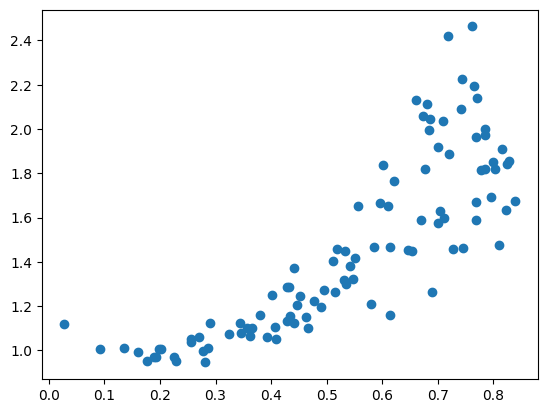

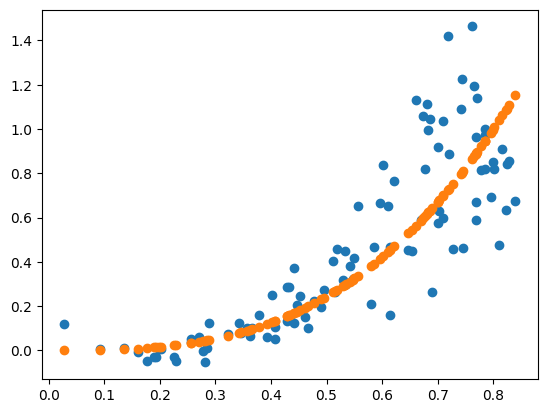

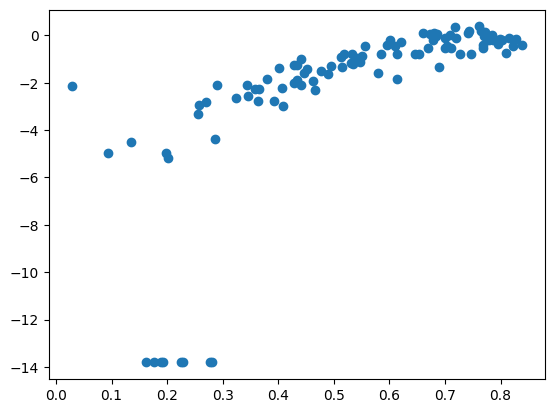

In [14]:
ratio_vals = nu_over_d_XTX_vals / estimate_nu_over_d_XTX_vals
plt.scatter(nu_over_d_X_vals, ratio_vals)
plt.show()

excess_ratio_vals = ratio_vals - 1.0
approx_one_vals = np.zeros(len(nu_over_d_X_vals))
for i in range(len(nu_over_d_X_vals)):
    nu_over_d = nu_over_d_X_vals[i]
    this_approx = (1.25 * nu_over_d)**3
    approx_one_vals[i] = this_approx


plt.scatter(nu_over_d_X_vals, excess_ratio_vals)
plt.scatter(nu_over_d_X_vals, approx_one_vals)
plt.show()

log_excess_ratio_vals = this_vec_log(ratio_vals - 1.0)
plt.scatter(nu_over_d_X_vals, log_excess_ratio_vals)
plt.show()

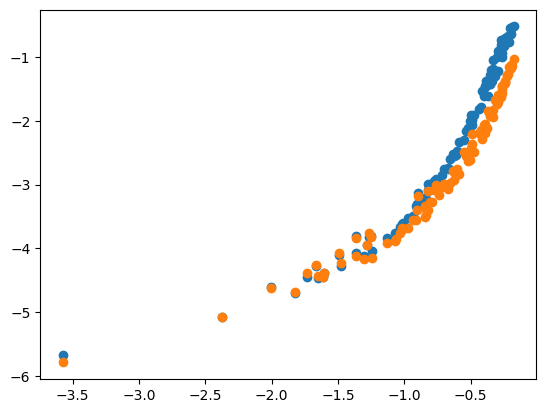

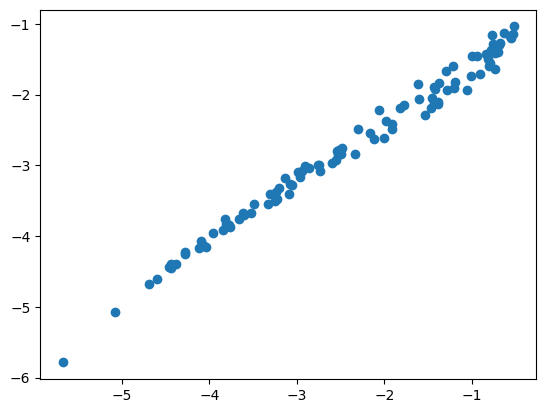

In [7]:
log_nu_over_d_X_vals = this_vec_log(nu_over_d_X_vals)
log_nu_over_d_XTX_vals = this_vec_log(nu_over_d_XTX_vals)
log_estimate_nu_over_d_XTX_vals = this_vec_log(estimate_nu_over_d_XTX_vals)

plt.scatter(log_nu_over_d_X_vals, log_nu_over_d_XTX_vals)
plt.scatter(log_nu_over_d_X_vals, log_estimate_nu_over_d_XTX_vals)
plt.show()

#plt.scatter(log_nu_over_d_X_vals, log_nu_over_d_XTX_vals)
plt.scatter(log_nu_over_d_XTX_vals, log_estimate_nu_over_d_XTX_vals)
plt.show()

In [6]:
def this_log(x):
  eps=1e-6
  return math.log(max(x,eps))

# Apply the function using np.vectorize
this_vec_log = np.vectorize(this_log)

In [24]:
#num_iterations = 100
these_nu_over_d_vals = np.arange(0.001,0.99,0.001)
these_alpha_vals = np.zeros(len(these_nu_over_d_vals))
d = 1000
i = 0 
for nu_over_d in these_nu_over_d_vals:
    this_alpha = pp.calculate_alpha_given_nu_over_d_and_d(nu_over_d, d)
    these_alpha_vals[i] = this_alpha
    i += 1
    

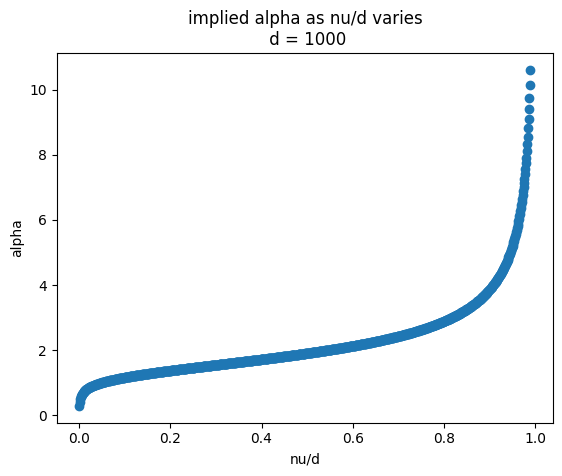

In [26]:
this_title = "implied alpha as nu/d varies\n d = " + str(d)
plt.scatter(these_nu_over_d_vals, these_alpha_vals)
plt.xlabel("nu/d")
plt.ylabel("alpha")
plt.title(this_title)
plt.show()